In [2]:
import pandas as pd

In [3]:
ames = pd.read_csv("ames.csv")
ames.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price,Longitude,Latitude,Bonus,id
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141,31770,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,...,0,5,2010,WD,Normal,215000,-93.619754,42.054035,1,1
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80,11622,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,...,0,6,2010,WD,Normal,105000,-93.619756,42.053014,0,2
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81,14267,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,...,12500,6,2010,WD,Normal,172000,-93.619387,42.052659,0,3
3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,93,11160,Pave,No_Alley_Access,Regular,Lvl,AllPub,Corner,...,0,4,2010,WD,Normal,244000,-93.617320,42.051245,1,4
4,Two_Story_1946_and_Newer,Residential_Low_Density,74,13830,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,...,0,3,2010,WD,Normal,189900,-93.638933,42.060899,1,5


In [4]:
ames.shape

(2930, 83)

In [5]:
ames.columns

Index(['MS_SubClass', 'MS_Zoning', 'Lot_Frontage', 'Lot_Area', 'Street',
       'Alley', 'Lot_Shape', 'Land_Contour', 'Utilities', 'Lot_Config',
       'Land_Slope', 'Neighborhood', 'Condition_1', 'Condition_2', 'Bldg_Type',
       'House_Style', 'Overall_Qual', 'Overall_Cond', 'Year_Built',
       'Year_Remod_Add', 'Roof_Style', 'Roof_Matl', 'Exterior_1st',
       'Exterior_2nd', 'Mas_Vnr_Type', 'Mas_Vnr_Area', 'Exter_Qual',
       'Exter_Cond', 'Foundation', 'Bsmt_Qual', 'Bsmt_Cond', 'Bsmt_Exposure',
       'BsmtFin_Type_1', 'BsmtFin_SF_1', 'BsmtFin_Type_2', 'BsmtFin_SF_2',
       'Bsmt_Unf_SF', 'Total_Bsmt_SF', 'Heating', 'Heating_QC', 'Central_Air',
       'Electrical', 'First_Flr_SF', 'Second_Flr_SF', 'Low_Qual_Fin_SF',
       'Gr_Liv_Area', 'Bsmt_Full_Bath', 'Bsmt_Half_Bath', 'Full_Bath',
       'Half_Bath', 'Bedroom_AbvGr', 'Kitchen_AbvGr', 'Kitchen_Qual',
       'TotRms_AbvGrd', 'Functional', 'Fireplaces', 'Fireplace_Qu',
       'Garage_Type', 'Garage_Finish', 'Garage_Cars', 'G

In [6]:
cols_to_keep = ['Sale_Price', 'Street', 'Central_Air', 'Bedroom_AbvGr', 'Year_Built', 'Mo_Sold', 'Lot_Area',
       'First_Flr_SF', 'Second_Flr_SF', 'Fireplaces', 'Garage_Area', 'Gr_Liv_Area']

In [7]:
ames_update = ames[cols_to_keep]
ames_update.head()

,Sale_Price,Street,Central_Air,Bedroom_AbvGr,Year_Built,Mo_Sold,Lot_Area,First_Flr_SF,Second_Flr_SF,Fireplaces,Garage_Area,Gr_Liv_Area
0,215000,Pave,Y,3,1960,5,31770,1656,0,2,528,1656
1,105000,Pave,Y,2,1961,6,11622,896,0,0,730,896
2,172000,Pave,Y,3,1958,6,14267,1329,0,0,312,1329
3,244000,Pave,Y,3,1968,4,11160,2110,0,2,522,2110
4,189900,Pave,Y,3,1997,3,13830,928,701,1,482,1629


In [9]:
ames_update.columns

Index(['Sale_Price', 'Street', 'Central_Air', 'Bedroom_AbvGr', 'Year_Built',
       'Mo_Sold', 'Lot_Area', 'First_Flr_SF', 'Second_Flr_SF', 'Fireplaces',
       'Garage_Area', 'Gr_Liv_Area'],
      dtype='object')

In [8]:
X_train = ames_update[['Street', 'Central_Air', 'Bedroom_AbvGr', 'Year_Built',
       'Mo_Sold', 'Lot_Area', 'First_Flr_SF', 'Second_Flr_SF', 'Fireplaces',
       'Garage_Area', 'Gr_Liv_Area']]

y_train = ames_update[['Sale_Price']]

In [9]:
X_train = pd.get_dummies(X_train, columns=['Street','Central_Air']).astype(int)
X_train.head()

,Bedroom_AbvGr,Year_Built,Mo_Sold,Lot_Area,First_Flr_SF,Second_Flr_SF,Fireplaces,Garage_Area,Gr_Liv_Area,Street_Grvl,Street_Pave,Central_Air_N,Central_Air_Y
0,3,1960,5,31770,1656,0,2,528,1656,0,1,0,1
1,2,1961,6,11622,896,0,0,730,896,0,1,0,1
2,3,1958,6,14267,1329,0,0,312,1329,0,1,0,1
3,3,1968,4,11160,2110,0,2,522,2110,0,1,0,1
4,3,1997,3,13830,928,701,1,482,1629,0,1,0,1


#### Feature Selection

In [12]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

lm = LinearRegression()

model_cv = SequentialFeatureSelector(lm, n_features_to_select = "auto", direction = "backward", scoring = "neg_mean_squared_error", cv = 10)

model_cv.fit(X_train, y_train)

SequentialFeatureSelector(cv=10, direction='backward',
                          estimator=LinearRegression(),
                          scoring='neg_mean_squared_error')

In [13]:
model_cv.get_feature_names_out()

array(['Bedroom_AbvGr', 'Year_Built', 'First_Flr_SF', 'Second_Flr_SF',
       'Fireplaces', 'Garage_Area', 'Gr_Liv_Area'], dtype=object)

##### Classical Model with this Variable Selection

In [14]:
import statsmodels.formula.api as smf

final_model1 = smf.ols("Sale_Price ~ Bedroom_AbvGr + Year_Built + Mo_Sold + Lot_Area + First_Flr_SF + Second_Flr_SF + Fireplaces + Garage_Area", data = ames_update).fit()

final_model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Sale_Price   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     1037.
Date:                Mon, 11 Nov 2024   Prob (F-statistic):               0.00
Time:                        09:16:49   Log-Likelihood:                -35261.
No. Observations:                2930   AIC:                         7.054e+04
Df Residuals:                    2921   BIC:                         7.059e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      -1.45e+06   5.65e+04    -25.657      0.000   -1.56e+06   -1.34e+06
Bedroom_AbvGr -1.297e+04   1142.895    -11.344      0.000   -1.52e+04   -1.07e+04
Year_Built      749.5293     29.003     25.843      0.000     692.660     806.398
Mo_Sold          45.7333    278.614      0.164      0.870    -500.567     592.034
Lot_Area          0.3064      0.104      2.949      0.003       0.103       0.510
First_Flr_SF    106.4337      2.841     37.463      0.000     100.863     112.004
Second_Flr_SF    79.1560      2.452     32.278      0.000      74.347      83.964
Fireplaces     1.191e+04   1364.597      8.731      0.000    9239.287    1.46e+04
Garage_Area      62.3909      4.611     13.530      0.000      53.349      71.433
==============================================================================
Omnibus:                     1066.666   Durbin-Watson:                   1.418
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            93443.784
Skew:                          -0.791   Prob(JB):                         0.00
Kurtosis:                      30.621   Cond. No.                     9.73e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.73e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

##### ML Approach

In [15]:
final_model2 = SequentialFeatureSelector(lm, n_features_to_select = 8, direction = "backward", scoring = "neg_mean_squared_error")

final_model2.fit(X_train, y_train)

SequentialFeatureSelector(direction='backward', estimator=LinearRegression(),
                          n_features_to_select=8,
                          scoring='neg_mean_squared_error')

In [16]:
final_model2.get_feature_names_out()

array(['Bedroom_AbvGr', 'Year_Built', 'First_Flr_SF', 'Second_Flr_SF',
       'Fireplaces', 'Garage_Area', 'Gr_Liv_Area', 'Central_Air_N'],
      dtype=object)

##### Regularization with Elastic Net

In [17]:
from sklearn.linear_model import ElasticNetCV

en_model = ElasticNetCV(cv = 10, l1_ratio = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], n_alphas = 100)

en_model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:1623: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


ElasticNetCV(cv=10, l1_ratio=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

##### Get the optimal Lambda and Alpha levels, to optimize balance between Ridge and Lasso Regressions, and the penalty terms
- 0 = Ridge
- 1 = Lasso

Lambda Value - set by looking at min SSE for many different values of lambda, then picking the optimal value

In [18]:
en_model.alpha_

186375.2738584587

Alpha Value

In [19]:
en_model.l1_ratio_

0.9

Build the plot, to Visualize the selection process

In [20]:
import numpy as np
from sklearn.linear_model import ElasticNet
from matplotlib import pyplot as plt
import seaborn as sns

n_alphas = 100
alphas3 = np.logspace(1, 8, n_alphas)

coefs3 = []
for a in alphas3:
    en = ElasticNet(alpha = a, l1_ratio=0.9)
    en.fit(X_train, y_train)
    coefs3.append(en.coef_)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.773e+11, tolerance: 1.869e+09
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.580e+11, tolerance: 1.869e+09
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.107e+11, toler

(4.46683592150963, 223872113.8568338, -4799.08794652112, 3624.214884261797)

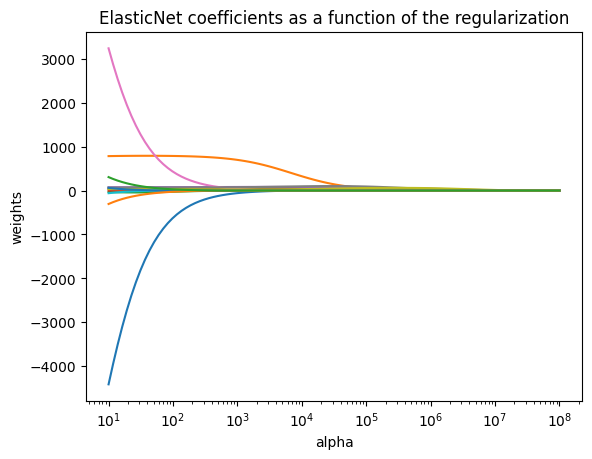

In [21]:
    
plt.cla()
ax3 = plt.gca()

ax3.plot(alphas3, coefs3)
ax3.set_xscale("log")
plt.xlabel("alpha")
plt.ylabel("weights")
plt.title("ElasticNet coefficients as a function of the regularization")
plt.axis("tight")

### i.Linear and Additive Models

#### 1.General Additive Model
- can be used for CAT and CONT target variables
- used to add multiple non-linear functions together

##### A. Piecewise Linear Regression

In [22]:
cement = pd.read_csv("cement.csv")
cement.head()

,BATCH,STRENGTH,RATIO,X2,X2STAR
0,1,4.67,47,0,0
1,2,3.54,68,0,0
2,3,2.25,75,1,5
3,4,3.82,65,0,0
4,5,4.50,50,0,0


In [23]:
import statsmodels.formula.api as smf
from matplotlib import pyplot as plt
import seaborn as sns

cement_lm = smf.ols("STRENGTH ~ RATIO + X2STAR", data = cement).fit()

cement_lm.summary()

/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               STRENGTH   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     114.4
Date:                Mon, 11 Nov 2024   Prob (F-statistic):           8.26e-10
Time:                        09:16:53   Log-Likelihood:                -3.8688
No. Observations:                  18   AIC:                             13.74
Df Residuals:                      15   BIC:                             16.41
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.7920      0.677     11.510      0.000       6.349       9.235
RATIO         -0.0663      0.011     -5.904      0.000      -0.090      -0.042
X2STAR        -0.1012      0.028     -3.598      0.003      -0.161      -0.041
==============================================================================
Omnibus:                        1.877   Durbin-Watson:                   2.303
Prob(Omnibus):                  0.391   Jarque-Bera (JB):                1.074
Skew:                          -0.597   Prob(JB):                        0.585
Kurtosis:                       2.930   Cond. No.                         582.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Visual for the Piecewise Linear Regression

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


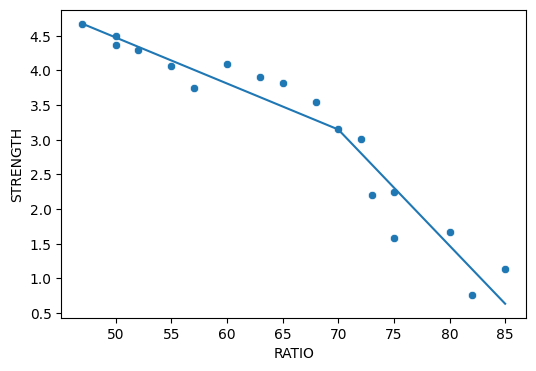

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(x = 'RATIO', y='STRENGTH', data = cement, ax = ax)

x_pred = cement['RATIO']
y_pred = cement_lm.fittedvalues

sns.lineplot(x = x_pred, y = y_pred, ax = ax)

plt.show()

Visual for a Piece-wise, Discontinuous Extension

In [25]:
cement_lm = smf.ols("STRENGTH ~ RATIO + X2STAR + X2", data = cement).fit()

cement_lm.summary()

/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               STRENGTH   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     98.57
Date:                Mon, 11 Nov 2024   Prob (F-statistic):           1.19e-09
Time:                        09:16:53   Log-Likelihood:                -1.0976
No. Observations:                  18   AIC:                             10.20
Df Residuals:                      14   BIC:                             13.76
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.0498      0.686     10.283      0.000       5.579       8.520
RATIO         -0.0524      0.012     -4.463      0.001      -0.078      -0.027
X2STAR        -0.0789      0.027     -2.937      0.011      -0.136      -0.021
X2            -0.6039      0.269     -2.247      0.041      -1.180      -0.027
==============================================================================
Omnibus:                        0.555   Durbin-Watson:                   2.336
Prob(Omnibus):                  0.758   Jarque-Bera (JB):                0.446
Skew:                          -0.340   Prob(JB):                        0.800
Kurtosis:                       2.634   Cond. No.                         678.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


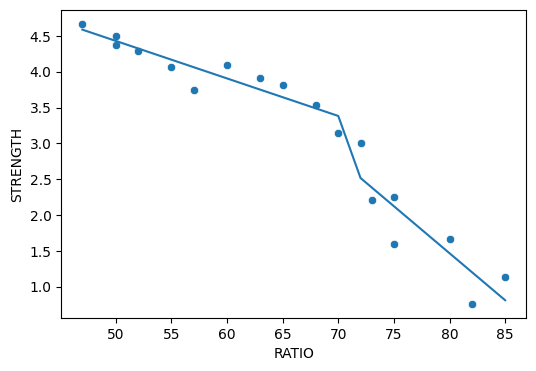

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(x = 'RATIO', y='STRENGTH', data = cement, ax = ax)

x_pred = cement['RATIO']
y_pred = cement_lm.fittedvalues

sns.lineplot(x = x_pred, y = y_pred, ax = ax)

plt.show()

##### B. MARS
- this has to be done with an R wrapper in Python, Python library has not been updated since 2017

##### C. Smoothing Splines

In [27]:
### code in ML_hw nb

#### 2.Random Forest
- can be used for CAT and CONT target variables
- voting ensemble of many, many trees
- dfs: amesupdate, X_train, y_train

In [10]:
X_train.head()

,Bedroom_AbvGr,Year_Built,Mo_Sold,Lot_Area,First_Flr_SF,Second_Flr_SF,Fireplaces,Garage_Area,Gr_Liv_Area,Street_Grvl,Street_Pave,Central_Air_N,Central_Air_Y
0,3,1960,5,31770,1656,0,2,528,1656,0,1,0,1
1,2,1961,6,11622,896,0,0,730,896,0,1,0,1
2,3,1958,6,14267,1329,0,0,312,1329,0,1,0,1
3,3,1968,4,11160,2110,0,2,522,2110,0,1,0,1
4,3,1997,3,13830,928,701,1,482,1629,0,1,0,1


In [29]:
y_train.head()

,Sale_Price
0,215000
1,105000
2,172000
3,244000
4,189900


In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_ames = RandomForestRegressor(n_estimators = 100,
                                  random_state = 12345,
                                  oob_score = True)

rf_ames.fit(X_train, y_train.iloc[:,0])

RandomForestRegressor(oob_score=True, random_state=12345)

In [31]:
rf_ames.oob_score_

0.8664832146774124

Variable Importance

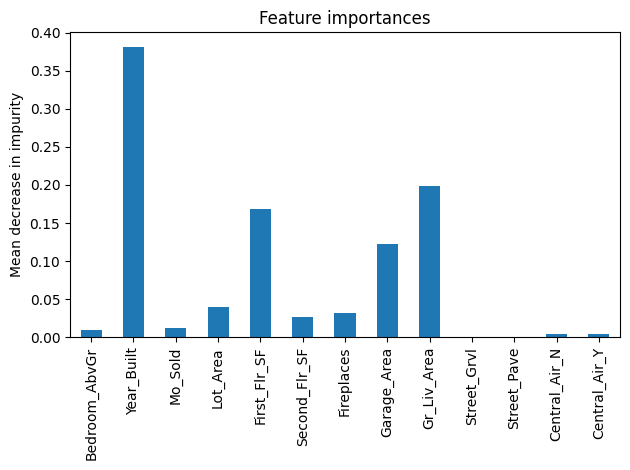

In [32]:
from matplotlib import pyplot as plt
import seaborn as sns

forest_importances = pd.Series(rf_ames.feature_importances_, index = rf_ames.feature_names_in_)

fig, ax = plt.subplots()
forest_importances.plot.bar(ax = ax)
ax.set_title("Feature importances")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

plt.show()

Parameter Tuning

In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'bootstrap': [True], ##enable this
    'max_features': [3, 4, 5, 6, 7], ##number of features
    'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800] ##number of trees
}

rf = RandomForestRegressor(random_state = 12345)

grid_search = GridSearchCV(estimator = rf, param_grid = param_grid, cv = 10)

grid_search.fit(X_train, y_train.iloc[:,0])

GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=12345),
             param_grid={'bootstrap': [True], 'max_features': [3, 4, 5, 6, 7],
                         'n_estimators': [100, 200, 300, 400, 500, 600, 700,
                                          800]})

In [34]:
grid_search.best_params_

{'bootstrap': True, 'max_features': 4, 'n_estimators': 700}

Variable Selection

In [36]:
import numpy as np

X_train_r = X_train

X_train_r['random'] = np.random.normal(0, 1, 2930)

Compare variable against a random number. If random number outperforms

### ii.Gradient Boosting Models

##### 1.XGBoost

In [37]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


Initialization

In [39]:
from xgboost import XGBRegressor

xgb_ames = XGBRegressor(n_estimators = 50, #number of trees,
                        subsample = 0.5, #stochastic gradient descent,
                        random_state = 12345)

xgb_ames.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=50, n_jobs=None,
             num_parallel_tree=None, random_state=12345, ...)

Parameter Tuning

In [40]:
param_grid = {
    'n_estimators': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
    'eta': [0.1, 0.15, 0.2, 0.25, 0.3],
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'subsample': [0.25, 0.5, 0.75, 1]
}

xgb = XGBRegressor()

grid_search = GridSearchCV(estimator = xgb, param_grid = param_grid, cv = 10)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None,...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             param_grid={'eta': [0.1, 0.15, 0.2, 0.25, 0.3],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'n_estimators': [5, 10, 15, 20, 25, 30, 35, 40, 45,
                                          50],
                         'subsample': [0.25, 0.5, 0.75, 1]})

In [41]:
grid_search.best_params_

{'eta': 0.15, 'max_depth': 5, 'n_estimators': 40, 'subsample': 0.75}

Variable Importance and Selection

In [42]:
xgb_ames = XGBRegressor(n_estimators = 50,
                        subsample = 0.75,
                        eta = 0.15,
                        max_depth = 5,
                        random_state = 12345)

xgb_ames.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eta=0.15, eval_metric=None,
             feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

Visual 1 - Var Importance

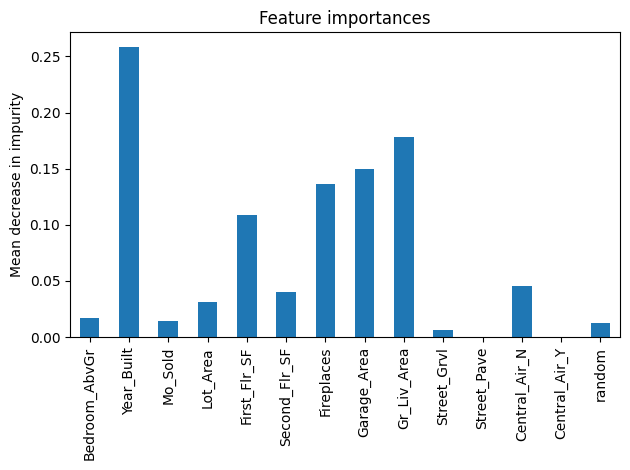

In [43]:
forest_importances = pd.Series(xgb_ames.feature_importances_, index = xgb_ames.feature_names_in_)

fig, ax = plt.subplots()
forest_importances.plot.bar(ax = ax)
ax.set_title("Feature importances")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

plt.show()

Visual 2 - Var Importance

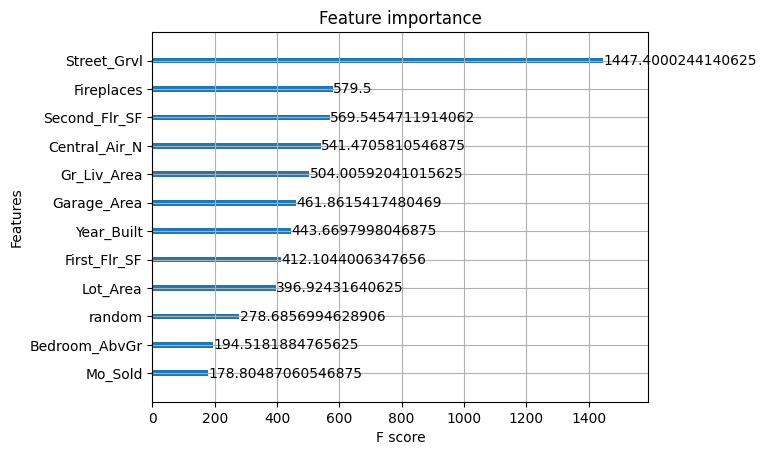

In [44]:
import xgboost

xgboost.plot_importance(xgb_ames, importance_type = 'cover')

plt.show()

Adding the Random Variable to Baseline variable importance

In [45]:
import numpy as np

X_train_r = X_train

X_train_r['random'] = np.random.normal(0, 1, 2930)

In [46]:
xgb_ames = XGBRegressor(n_estimators = 50,
                        subsample = 0.75,
                        eta = 0.15,
                        max_depth = 5,
                        random_state = 12345)

xgb_ames.fit(X_train_r, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eta=0.15, eval_metric=None,
             feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

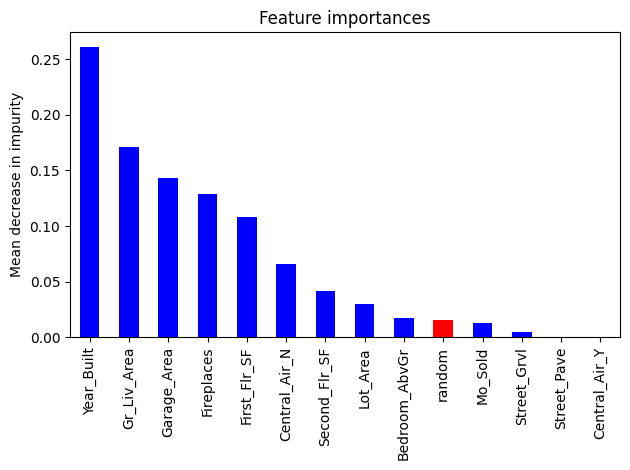

In [47]:
forest_importances = pd.Series(xgb_ames.feature_importances_, index = xgb_ames.feature_names_in_)
forest_importances = forest_importances.sort_values(ascending=False)

colors = ['red' if feature == 'random' else 'blue' for feature in forest_importances.index]

fig, ax = plt.subplots()
forest_importances.plot.bar(ax = ax, color=colors)
ax.set_title("Feature importances")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

plt.show()

In [48]:
import xgboost as xgb
import pandas as pd

# Assuming `xgb_ins` is your trained XGBoost model instance

booster = xgb_ames.get_booster()

# Get feature importance by gain, coverage, and frequency
importance_types = ['weight', 'gain', 'cover']  # weight: frequency, gain, cover: coverage

# Collect each importance type into a dictionary
importance_dict = {imp_type: booster.get_score(importance_type=imp_type) for imp_type in importance_types}

# Convert dictionaries to DataFrames, then merge them to get all values in a single DataFrame
importance_df = pd.DataFrame.from_dict(importance_dict)

# Rename columns for clarity
importance_df.columns = ['Frequency', 'Gain', 'Coverage']

# Fill NaN values with 0 (in case some features have missing importance metrics)
importance_df = importance_df.fillna(0)

# Sort by 'Gain' or another metric if desired
importance_df = importance_df.sort_values(by='Gain', ascending=False)

print(importance_df)


               Frequency          Gain    Coverage
Year_Built         208.0  8.919656e+10  438.884613
Gr_Liv_Area        176.0  5.838849e+10  531.420471
Garage_Area        141.0  4.883923e+10  423.602844
Fireplaces          51.0  4.386673e+10  534.568604
First_Flr_SF       186.0  3.704254e+10  472.494629
Central_Air_N       11.0  2.249875e+10  782.000000
Second_Flr_SF       80.0  1.426516e+10  532.599976
Lot_Area           189.0  1.012880e+10  362.783081
Bedroom_AbvGr      106.0  5.991483e+09  219.462265
random              92.0  5.325385e+09  253.978256
Mo_Sold             83.0  4.325290e+09  218.289154
Street_Grvl          7.0  1.531372e+09  625.000000


Partial Dependence Plots

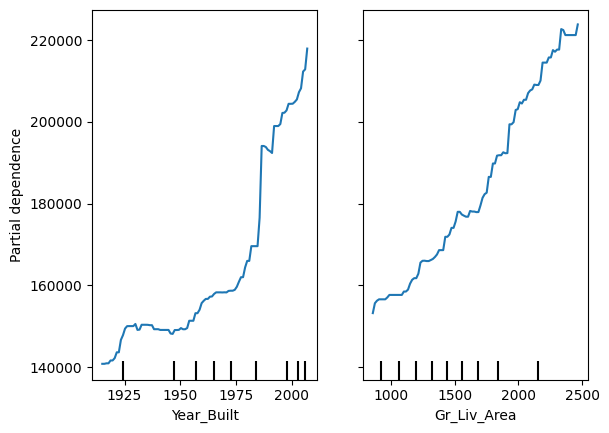

In [49]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features = [forest_importances.index[0], forest_importances.index[1]]
PartialDependenceDisplay.from_estimator(xgb_ames, X_train, features=features, kind="average")
plt.show()


##### 2.EBM: Explainable Boosting Machines
- build the model one variable at a time
- build additional models on the residual errors

In [50]:
pip install interpret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 13.2 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 12.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.3/348.3 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 13.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 778.9/778.9 kB 12.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.5/272.5 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 8.6 MB/s eta 0:00:00
  Created wheel for dash-cytoscape: filename=dash_cytoscape-1.0.2-py3-none-any.whl size=4010715 sha256=9c1e055b52566e035e93aac8cc5c6d79507a3a4b989b64a37a9e0162b104add5
  Stored in directory: /Users/fre

In [51]:
import interpret
from interpret.glassbox import ExplainableBoostingRegressor
from interpret.glassbox import ExplainableBoostingClassifier
from interpret.blackbox import PartialDependence
from interpret import show

In [53]:


# Fit a glassbox model, like Explainable Boosting Machine (EBM), for demonstration
ebm = ExplainableBoostingClassifier(interactions=5)
ebm.fit(X_train, y_train)

# Use Partial Dependence for blackbox models, like an XGBoost or other complex models
pdp_global = ebm.explain_global(X_train)

# Visualize the partial dependence
show(pdp_global)


/opt/anaconda3/lib/python3.11/site-packages/interpret/glassbox/_ebm/_utils.py:379: UserWarning: Too few samples per class, adapting test size to guarantee 1 sample per class.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:1019: UserWarning: Detected multiclass problem. Forcing interactions to 0. Multiclass interactions only have local explanations. They are not currently displayed in the global explanation visualizations. Set interactions=0 to disable this warning. If you still want multiclass interactions, this API accepts a list, and the measure_interactions function can be used to detect them.
  warn(


<!-- http://127.0.0.1:7001/6243133136/ -->

### iii.Neural Networks

In [54]:
# Data needs to be scaled
from sklearn.preprocessing import StandardScaler  

scaler = StandardScaler()  
scaler.fit(X_train)

StandardScaler()

In [55]:
X_train_s = scaler.transform(X_train) 

In [ ]:
pip install

In [64]:
y_train_flat = y_train.values.ravel()

In [65]:
from sklearn.neural_network import MLPRegressor

nn_ames = MLPRegressor(solver='lbfgs', alpha = 1e-5,
                       hidden_layer_sizes = (5,),
                       random_state = 12345)
                       
nn_ames.fit(X_train_s, y_train_flat)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html



MLPRegressor(alpha=1e-05, hidden_layer_sizes=(5,), random_state=12345,
             solver='lbfgs')

In [66]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'hidden_layer_sizes': [3, 4, 5, 6, 7],
    'alpha': [0.00005, 0.0005],
    'solver': ['lbfgs']
}

nn = MLPRegressor(max_iter = 5000, random_state = 12345)

grid_search = GridSearchCV(estimator = nn, param_grid = param_grid, cv = 10)

grid_search.fit(X_train_s, y_train_flat)

GridSearchCV(cv=10, estimator=MLPRegressor(max_iter=5000, random_state=12345),
             param_grid={'alpha': [5e-05, 0.0005],
                         'hidden_layer_sizes': [3, 4, 5, 6, 7],
                         'solver': ['lbfgs']})

In [67]:
grid_search.best_params_

{'alpha': 0.0005, 'hidden_layer_sizes': 6, 'solver': 'lbfgs'}

### iv.Naive Bayes

In [68]:
import pandas as pd

train_dummy = pd.get_dummies(ames_update, columns = ['Street', 'Central_Air'])

print(train_dummy)

      Sale_Price  Bedroom_AbvGr  Year_Built  Mo_Sold  Lot_Area  First_Flr_SF  \
0         215000              3        1960        5     31770          1656   
1         105000              2        1961        6     11622           896   
2         172000              3        1958        6     14267          1329   
3         244000              3        1968        4     11160          2110   
4         189900              3        1997        3     13830           928   
...          ...            ...         ...      ...       ...           ...   
2925      142500              3        1984        3      7937          1003   
2926      131000              2        1983        6      8885           902   
2927      132000              3        1992        7     10441           970   
2928      170000              2        1974        4     10010          1389   
2929      188000              3        1993       11      9627           996   

      Second_Flr_SF  Fireplaces  Garage

In [70]:
train_dummy['Bonus'] = (train_dummy['Sale_Price']>175000).astype(int)

In [71]:
y_train_c = train_dummy['Bonus']

X_train_c = train_dummy.loc[:, train_dummy.columns != 'Bonus']

In [72]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train_c, y_train_c)

GaussianNB()

### v. Model Agnostic Evaluation

##### i. Permutation Importance - Global

In [11]:
pip install scikit-learn matplotlib pandas


Note: you may need to restart the kernel to use updated packages.


In [12]:
from sklearn.ensemble import RandomForestRegressor

rf_ames = RandomForestRegressor(n_estimators = 100,
                                  random_state = 12345,
                                  max_features = 7,
                                  oob_score = True)

rf_ames.fit(X_train, y_train.values.flatten())

RandomForestRegressor(max_features=7, oob_score=True, random_state=12345)

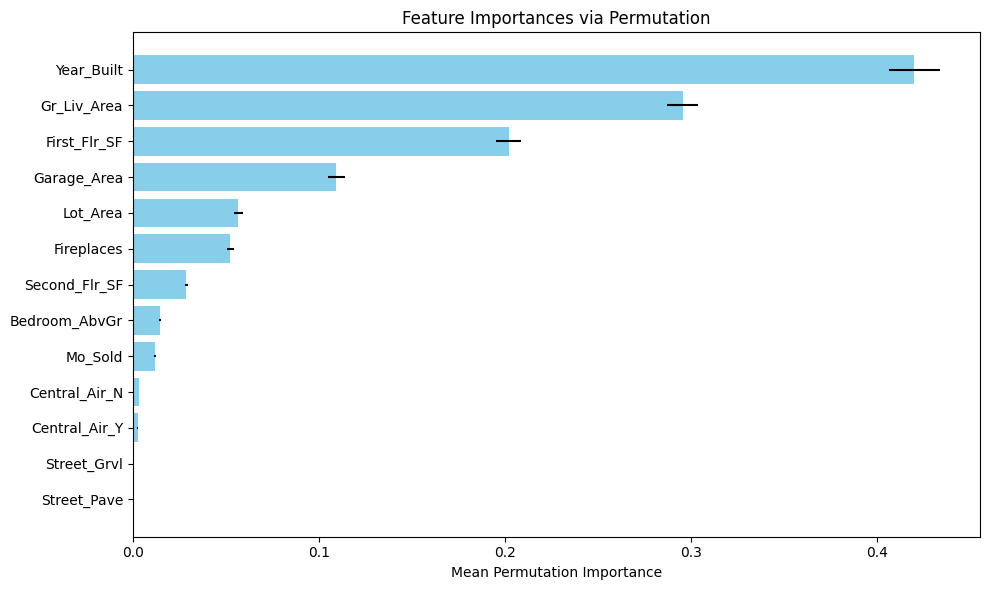

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

feature_names = [f"Feature {i}" for i in range(1, 11)]

# Permutation importance
result = permutation_importance(rf_ames, X_train, y_train, n_repeats=10, random_state=42, scoring='r2')

# Get importances and feature indices
importances = result.importances_mean
indices = np.argsort(importances)  # Sort feature indices by importance
sorted_feature_names = X_train.columns[indices]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(sorted_feature_names, importances[indices], xerr=result.importances_std[indices], align='center', color='skyblue')
plt.xlabel("Mean Permutation Importance")
plt.title("Feature Importances via Permutation")
plt.tight_layout()
plt.show()

##### i. Individual Conditional Expectation (ECF) - Local method

In [1]:
pip install scikit-explain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.1/35.1 MB 50.2 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import skexplain